# Langevin sampling: diffusion limits, discretization bias, and correction

Langevin methods use gradients to turn local geometry into directed proposals. The
continuous diffusion can have the desired invariant law exactly, while a finite Euler
step generally introduces bias. Metropolis adjustment trades some movement for exact
invariance.

**Output semantics.** Euler--Maruyama and ULA are approximate at fixed step size. MALA
is an exact-invariant Markov chain because it evaluates the full asymmetric Hastings
ratio. All numerical conclusions below use explicit random-number generators.


In [1]:
import importlib.metadata
import os

import matplotlib.pyplot as plt
import numpy as np

from sampler_lab import spawn_rngs
from sampler_lab.diagnostics import empirical_integrated_autocorrelation_time
from sampler_lab.dynamics import (
    EulerMaruyamaKernel,
    MetropolisAdjustedLangevinKernel,
    UnadjustedLangevinKernel,
    estimate_local_moments,
    gaussian_ula_analysis,
    linear_gaussian_iat,
)
from sampler_lab.experiments import (
    run_langevin_gaussian_experiment,
    run_metropolis_generator_experiment,
)
from sampler_lab.mcmc import run_chain
from sampler_lab.models import GaussianTarget

QUICK_MODE = os.environ.get("SAMPLER_LAB_NOTEBOOK_MODE") == "quick"
SEED = 2022
FIGURE_COUNT = 0


def finish_figure(fig):
    global FIGURE_COUNT
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    FIGURE_COUNT += 1


print("sampler-lab", importlib.metadata.version("sampler-lab"))
print("execution mode:", "quick" if QUICK_MODE else "publication")
print("master seed:", SEED)

sampler-lab 0.12.0
execution mode: publication
master seed: 2022


## 1. Euler--Maruyama and local diffusion diagnostics

For

$$
dX_t=b(X_t)\,dt+\sigma(X_t)\,dW_t,
$$

Euler--Maruyama advances by

$$
X_{n+1}=X_n+h b(X_n)+\sqrt{h}\,\sigma(X_n)Z_n.
$$

Repeated one-step moves from the *same* state estimate the local drift and covariance
rates. This is a conditional diagnostic, not a time average from one chain.


In [2]:
local_step = 0.04
local_state = np.array([0.75, -0.25])
local_kernel = EulerMaruyamaKernel(
    drift=lambda x: -x,
    diffusion_factor=lambda x: np.sqrt(2.0) * np.eye(x.size),
    step_size=local_step,
)
local_replications = 6000 if QUICK_MODE else 30000
local_rng = spawn_rngs(SEED + 10, 1)[0]
local = estimate_local_moments(
    local_kernel,
    local_state,
    local_step,
    local_replications,
    local_rng,
)
print("estimated drift:", np.round(local.drift, 4))
print("exact drift:", -local_state)
print("estimated covariance rate:\n", np.round(local.centered_covariance_rate, 4))
print("exact covariance rate:\n", 2.0 * np.eye(2))

estimated drift: [-0.8106  0.2954]
exact drift: [-0.75  0.25]
estimated covariance rate:
 [[2.0038 0.0084]
 [0.0084 2.0127]]
exact covariance rate:
 [[2. 0.]
 [0. 2.]]


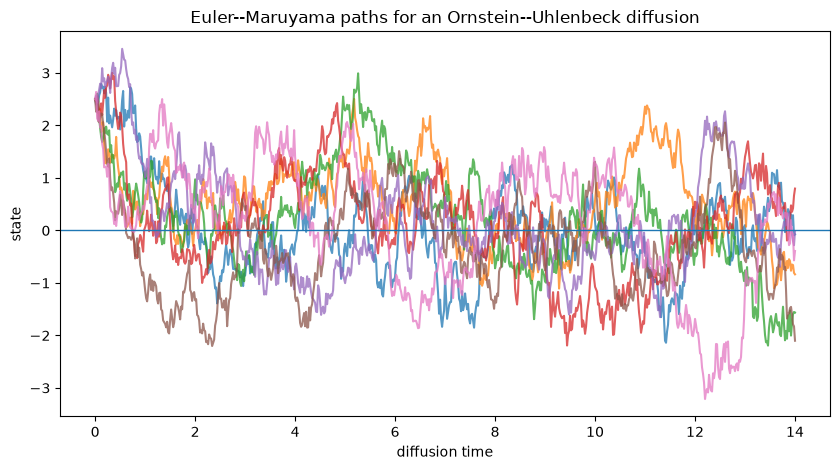

In [3]:
path_rngs = spawn_rngs(SEED + 20, 7)
n_path_steps = 260 if QUICK_MODE else 700
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for path_rng in path_rngs:
    state = np.array([2.5])
    values = [float(state[0])]
    kernel = EulerMaruyamaKernel(
        drift=lambda x: -x,
        diffusion_factor=lambda x: np.array([[np.sqrt(2.0)]]),
        step_size=0.02,
    )
    for _ in range(n_path_steps):
        state = kernel.step(state, path_rng).state
        values.append(float(state[0]))
    ax.plot(0.02 * np.arange(len(values)), values, alpha=0.75)
ax.axhline(0.0, linewidth=1.0)
ax.set_xlabel("diffusion time")
ax.set_ylabel("state")
ax.set_title("Euler--Maruyama paths for an Ornstein--Uhlenbeck diffusion")
finish_figure(fig)

## 2. Minimal ULA and MALA calls

For a target $\pi$ and constant preconditioner $M$, ULA proposes

$$
Y=x+hM\nabla\log\pi(x)+\sqrt{2hM}\,Z.
$$

MALA uses the same proposal but evaluates both Gaussian transition densities before
accepting or rejecting. Rejections remain in the trajectory; deleting them would create
the wrong jump chain.


In [4]:
target_covariance = np.array([[1.0, 0.94], [0.94, 1.0]])
target = GaussianTarget([0.0, 0.0], target_covariance)
minimal_steps = 3000 if QUICK_MODE else 12000
minimal_burn = 500 if QUICK_MODE else 1500
ula_rng, mala_rng = spawn_rngs(SEED + 30, 2)

ula = run_chain(
    UnadjustedLangevinKernel(target, 0.12),
    np.array([2.0, -2.0]),
    ula_rng,
    n_steps=minimal_steps,
)
mala = run_chain(
    MetropolisAdjustedLangevinKernel(target, 0.12),
    np.array([2.0, -2.0]),
    mala_rng,
    n_steps=minimal_steps,
)
ula_samples = ula.states[minimal_burn + 1 :]
mala_samples = mala.states[minimal_burn + 1 :]
ula_iat = empirical_integrated_autocorrelation_time(ula_samples[:, 0])
mala_iat = empirical_integrated_autocorrelation_time(mala_samples[:, 0])
print("empirical x1 IAT (ULA, MALA):", round(ula_iat, 2), round(mala_iat, 2))
print("MALA acceptance:", round(float(mala.acceptance_rate), 4))
print("ULA covariance:\n", np.round(np.cov(ula_samples.T), 3))
print("MALA covariance:\n", np.round(np.cov(mala_samples.T), 3))

empirical x1 IAT (ULA, MALA): 1.01 59.14
MALA acceptance: 0.5
ULA covariance:
 [[ 1666.728 -1664.848]
 [-1664.848  1666.796]]
MALA covariance:
 [[0.995 0.932]
 [0.932 0.988]]


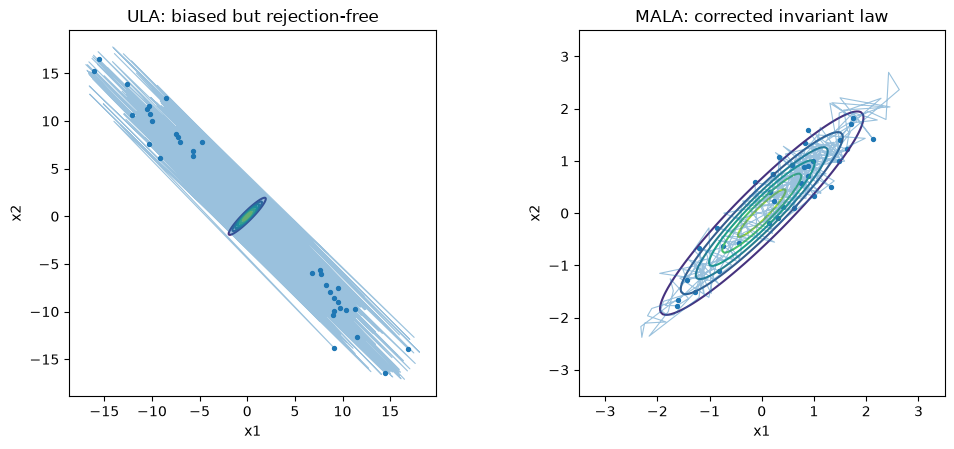

In [5]:
grid = np.linspace(-3.5, 3.5, 180)
xx, yy = np.meshgrid(grid, grid)
points = np.stack([xx, yy], axis=-1)
precision = np.linalg.inv(target_covariance)
density_levels = np.exp(-0.5 * np.einsum("...i,ij,...j->...", points, precision, points))
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
for ax, samples, title in (
    (axes[0], ula_samples, "ULA: biased but rejection-free"),
    (axes[1], mala_samples, "MALA: corrected invariant law"),
):
    ax.contour(xx, yy, density_levels, levels=6)
    ax.plot(samples[:500, 0], samples[:500, 1], alpha=0.45, linewidth=0.8)
    ax.scatter(samples[:500:15, 0], samples[:500:15, 1], s=8)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
finish_figure(fig)

## 3. Exact Gaussian stability and fixed-step bias

On a Gaussian target, ULA is a linear autoregression. The package can therefore compute
the stability boundary, stationary covariance, Gaussian KL error, and linear-observable
IAT exactly. Preconditioning removes the condition-number penalty, but not Euler bias.


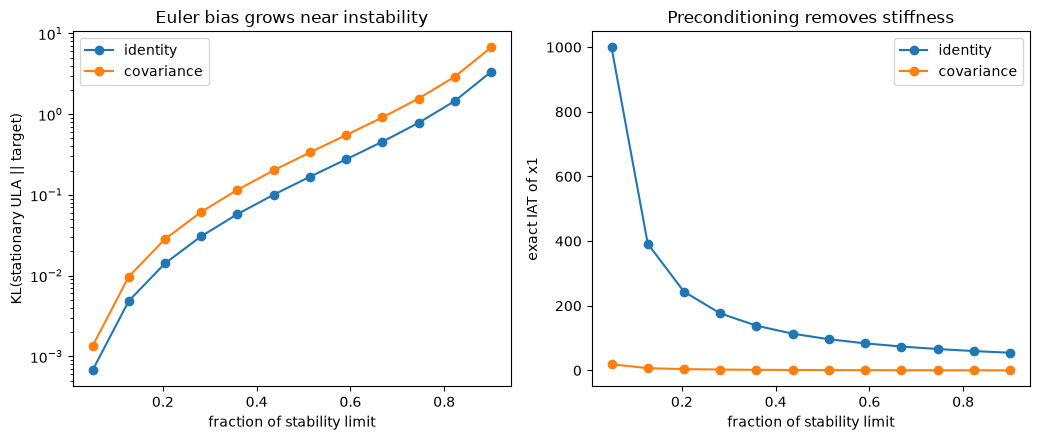

In [6]:
stiff_covariance = np.diag([1.0, 1.0 / 50.0])
stiff_target = GaussianTarget([0.0, 0.0], stiff_covariance)
fractions = np.linspace(0.05, 0.9, 12)
exact_rows = []
for label, preconditioner in (
    ("identity", None),
    ("covariance", stiff_covariance),
):
    reference = gaussian_ula_analysis(
        stiff_target,
        0.001,
        preconditioner=preconditioner,
    )
    for fraction in fractions:
        step = fraction * reference.maximum_stable_step_size
        analysis = gaussian_ula_analysis(
            stiff_target,
            step,
            preconditioner=preconditioner,
        )
        exact_rows.append(
            (
                label,
                fraction,
                step,
                float(analysis.kl_stationary_to_target),
                linear_gaussian_iat(
                    analysis.transition_matrix,
                    analysis.stationary_covariance,
                    np.array([1.0, 0.0]),
                ),
            )
        )

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
for label in ("identity", "covariance"):
    selected = np.array([row[1:] for row in exact_rows if row[0] == label])
    axes[0].plot(selected[:, 0], selected[:, 2], "o-", label=label)
    axes[1].plot(selected[:, 0], selected[:, 3], "o-", label=label)
axes[0].set_yscale("log")
axes[0].set_xlabel("fraction of stability limit")
axes[0].set_ylabel("KL(stationary ULA || target)")
axes[1].set_xlabel("fraction of stability limit")
axes[1].set_ylabel("exact IAT of x1")
axes[0].legend()
axes[1].legend()
axes[0].set_title("Euler bias grows near instability")
axes[1].set_title("Preconditioning removes stiffness")
finish_figure(fig)

## 4. CLI-matched conditioning experiment

This reproduces the target family, seed convention, and step-fraction convention used by
`sampler-lab-langevin-demo`. Identity ULA must respect the fastest coordinate, whereas
covariance-preconditioned ULA and MALA operate on a condition-number-free scale.


In [7]:
condition_numbers = (1.0, 10.0, 100.0)
experiment_rows = run_langevin_gaussian_experiment(
    condition_numbers=condition_numbers,
    n_samples=2500 if QUICK_MODE else 10000,
    burn_in=500 if QUICK_MODE else 1500,
    step_fraction=0.25,
    seed=SEED,
)
for row in experiment_rows:
    print(
        row.condition_number,
        row.method,
        "IAT=",
        round(row.empirical_iat, 3),
        "variance=",
        round(row.empirical_variance, 4),
        "accept=",
        None if row.acceptance_rate is None else round(row.acceptance_rate, 4),
    )

1.0 ULA identity IAT= 3.125 variance= 1.298 accept= None
1.0 ULA covariance IAT= 3.175 variance= 1.3561 accept= None
1.0 MALA covariance IAT= 3.012 variance= 1.0015 accept= 0.8789
10.0 ULA identity IAT= 38.327 variance= 1.0808 accept= None
10.0 ULA covariance IAT= 2.934 variance= 1.3365 accept= None
10.0 MALA covariance IAT= 2.837 variance= 1.0033 accept= 0.8796
100.0 ULA identity IAT= 231.805 variance= 0.8106 accept= None
100.0 ULA covariance IAT= 3.019 variance= 1.3192 accept= None
100.0 MALA covariance IAT= 3.227 variance= 1.0153 accept= 0.8781


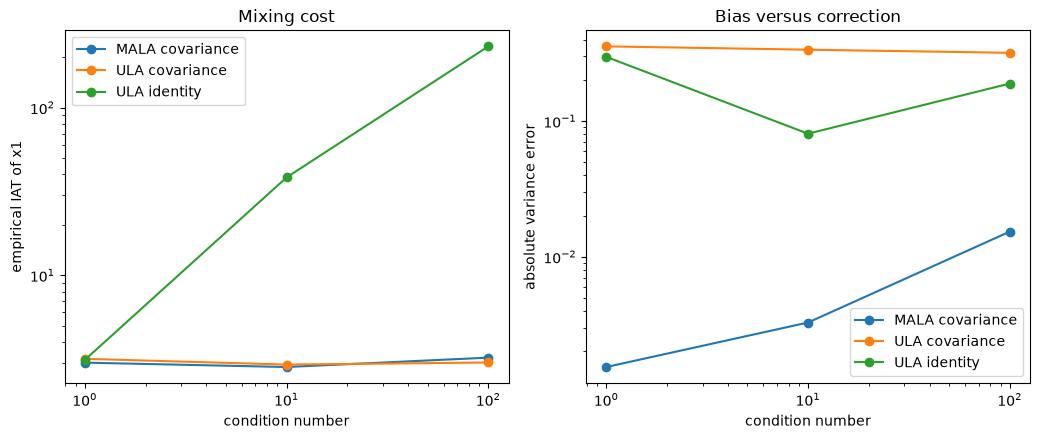

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
for method in sorted({row.method for row in experiment_rows}):
    chosen = [row for row in experiment_rows if row.method == method]
    axes[0].plot(
        [row.condition_number for row in chosen],
        [row.empirical_iat for row in chosen],
        "o-",
        label=method,
    )
    axes[1].plot(
        [row.condition_number for row in chosen],
        [abs(row.empirical_variance - row.target_variance) for row in chosen],
        "o-",
        label=method,
    )
for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("condition number")
    ax.legend()
axes[0].set_ylabel("empirical IAT of x1")
axes[1].set_ylabel("absolute variance error")
axes[0].set_title("Mixing cost")
axes[1].set_title("Bias versus correction")
finish_figure(fig)

## 5. Controlled failure: crossing the ULA stability boundary

The stability condition is not a vague tuning suggestion. Once the spectral radius of
the linear update exceeds one, the chain amplifies its stiff mode. A short trajectory is
enough to reveal the failure.


maximum stable step: 0.04
chosen unstable step: 0.0432
spectral radius: 1.1600000000000001


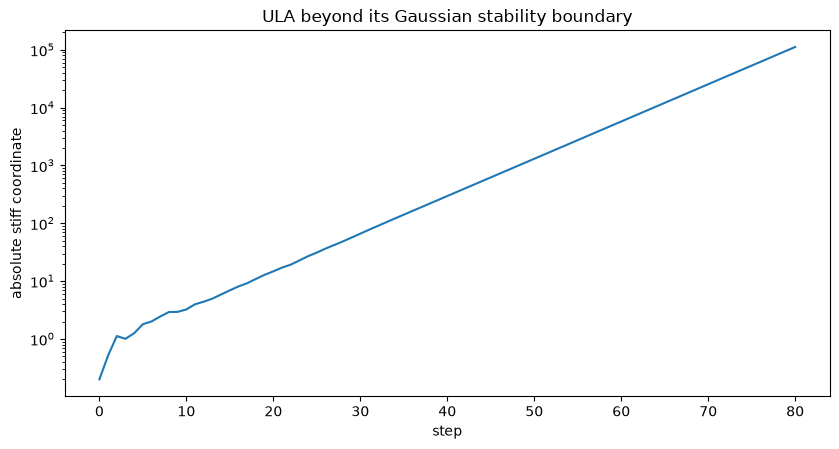

In [9]:
stable_reference = gaussian_ula_analysis(stiff_target, 0.001)
unstable_step = 1.08 * stable_reference.maximum_stable_step_size
unstable_analysis = gaussian_ula_analysis(stiff_target, unstable_step)
unstable_kernel = UnadjustedLangevinKernel(stiff_target, unstable_step)
unstable_rng = spawn_rngs(SEED + 50, 1)[0]
unstable_state = np.array([0.0, 0.2])
unstable_trace = [unstable_state.copy()]
for _ in range(80):
    unstable_state = unstable_kernel.step(unstable_state, unstable_rng).state
    unstable_trace.append(unstable_state.copy())
unstable_trace = np.asarray(unstable_trace)
print("maximum stable step:", stable_reference.maximum_stable_step_size)
print("chosen unstable step:", unstable_step)
print("spectral radius:", unstable_analysis.spectral_radius)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(np.abs(unstable_trace[:, 1]))
ax.set_yscale("log")
ax.set_xlabel("step")
ax.set_ylabel("absolute stiff coordinate")
ax.set_title("ULA beyond its Gaussian stability boundary")
finish_figure(fig)

## 6. A small-step Metropolis chain approaches the Langevin generator

Random-walk Metropolis with proposal variance $2h$ has a scaled generator that converges
to overdamped Langevin. The repository CLI estimates this conditional generator at a
fixed state; the error bars should cover the limiting value as $h$ shrinks.


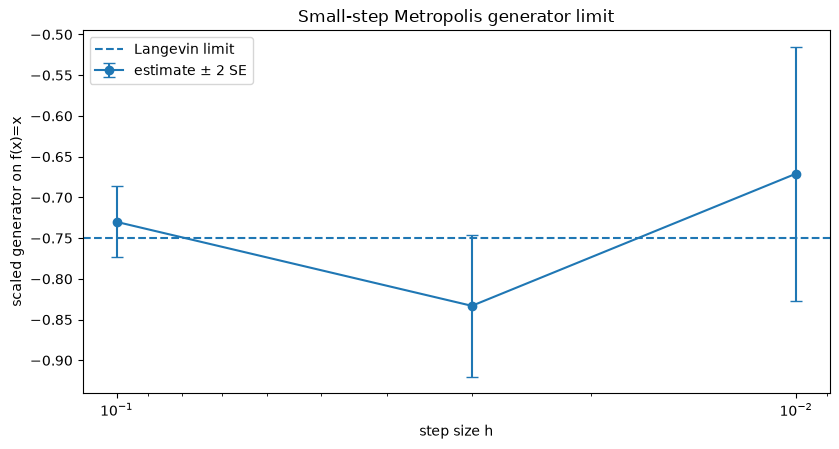

In [10]:
generator_rows = run_metropolis_generator_experiment(
    step_sizes=(0.1, 0.03, 0.01),
    n_replications=12000 if QUICK_MODE else 30000,
    state=0.75,
    seed=SEED,
)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.errorbar(
    [row.step_size for row in generator_rows],
    [row.estimate for row in generator_rows],
    yerr=[2.0 * row.standard_error for row in generator_rows],
    fmt="o-",
    capsize=4,
    label="estimate ± 2 SE",
)
ax.axhline(generator_rows[0].limiting_generator, linestyle="--", label="Langevin limit")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel("step size h")
ax.set_ylabel("scaled generator on f(x)=x")
ax.legend()
ax.set_title("Small-step Metropolis generator limit")
finish_figure(fig)

## When to use Langevin methods

- Use ULA when a small, controlled discretization error is acceptable and gradient cost
  dominates proposal correction.
- Use MALA when exact invariance matters and target-density evaluations are available.
- Precondition when the target has known or learnable anisotropy; the wrong coordinates
  can turn one easy Gaussian into a hundred-times slower chain.
- Inspect stability, acceptance, IAT, and moment bias together. No single number certifies
  a chain.

Further experiments: replace the constant covariance preconditioner by a functional
metric, include and omit its divergence correction, or verify the Poisson-equation bias
identity on a one-dimensional Gaussian.


In [11]:
drift_error = float(np.max(np.abs(local.drift + local_state)))
covariance_rate_error = float(np.max(np.abs(local.centered_covariance_rate - 2.0 * np.eye(2))))
by_key = {(row.condition_number, row.method): row for row in experiment_rows}
identity_stiff = by_key[(100.0, "ULA identity")]
preconditioned_stiff = by_key[(100.0, "ULA covariance")]
mala_stiff = by_key[(100.0, "MALA covariance")]
max_generator_z = max(abs(row.z_score) for row in generator_rows)

print("local drift max error:", round(drift_error, 4))
print("local covariance-rate max error:", round(covariance_rate_error, 4))
print("largest generator z-score:", round(max_generator_z, 3))

assert drift_error < (0.22 if QUICK_MODE else 0.11)
assert covariance_rate_error < (0.18 if QUICK_MODE else 0.09)
assert identity_stiff.exact_iat > 20.0 * preconditioned_stiff.exact_iat
assert mala_stiff.acceptance_rate is not None and mala_stiff.acceptance_rate > 0.75
assert max_generator_z < 4.5
assert unstable_analysis.spectral_radius > 1.0
assert FIGURE_COUNT >= 6
print(f"completed Langevin notebook with {FIGURE_COUNT} figures")

local drift max error: 0.0606
local covariance-rate max error: 0.0127
largest generator z-score: 1.914
completed Langevin notebook with 6 figures
